In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_series(pool_file: str,
                series_id: str = None,
                start: int = None,
                end: int = None,
                figsize: tuple = (14, 6),
                metadata_df: pd.DataFrame = None): 
    """  
    pool_file — путь к parquet-файлу ("data/S1.parquet")
    series_id — какой именно ряд рисовать
    start/end — срез по time_index
    metadata_df — DataFrame с метаданными (S1_metadata.parquet или S2_metadata.parquet)
    """
    df = pd.read_parquet(pool_file)
  
    if series_id is None:
        print(f"series_id не указан")
  
    series_df = df[df['series_id'] == series_id].copy()
    if series_df.empty:
        raise ValueError(f"Серия {series_id} не найдена в файле {pool_file}")
  
    if start is not None or end is not None:
        series_df = series_df.iloc[start:end]

    if metadata_df is not None and series_id in metadata_df['series_id'].values:
        anomaly_type = metadata_df.loc[metadata_df['series_id'] == series_id, 'anomaly_type'].iloc[0]
    
    x = series_df['time_index']
    y = series_df['value']
    anomalies = series_df['label'] == 1

    print(f"Серия: {series_id} | "
          f"Длина: {len(series_df):,} точек | "
          f"Аномалий: {anomalies.sum()} ({anomalies.mean():.1%}) | "
          f"Тип аномалии: {anomaly_type}")

    plt.figure(figsize=figsize)
    plt.plot(x, y, color='lightblue', linewidth=1.2, label='Value', zorder=1)
  
    if anomalies.any():
        plt.scatter(x[anomalies], y[anomalies],
                    color='red', s=10, zorder=2, label='Anomaly')

    plt.title(f'Серия: {series_id}\n'
              f'Длина: {len(series_df):,} точек | '
              f'Аномалий: {anomalies.sum()} ({anomalies.mean():.1%}) | '
              f'Тип аномалии: {anomaly_type}',
              fontsize=14)

    plt.xlabel('time_index')
    plt.ylabel('value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Серия: S1__SYNTH__ar2__0_full | Длина: 1,000 точек | Аномалий: 26 (2.6%) | Тип аномалии: level_shift


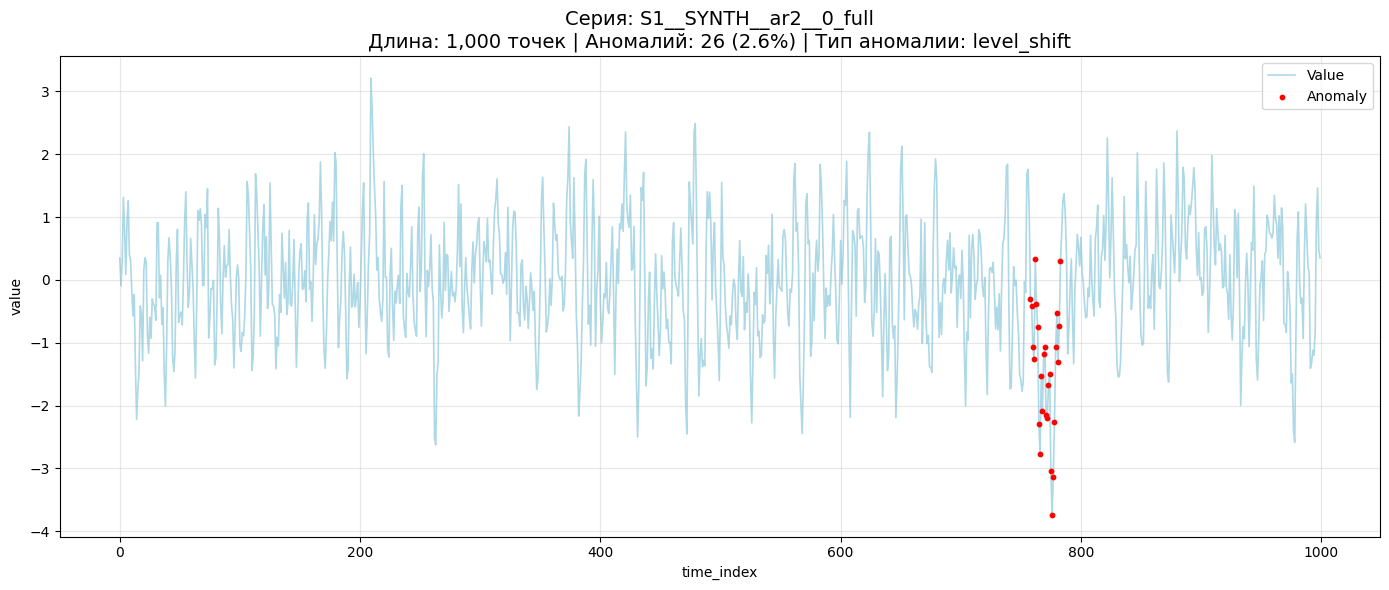

Серия: S1__SYNTH__ar2__1_full | Длина: 1,000 точек | Аномалий: 8 (0.8%) | Тип аномалии: point


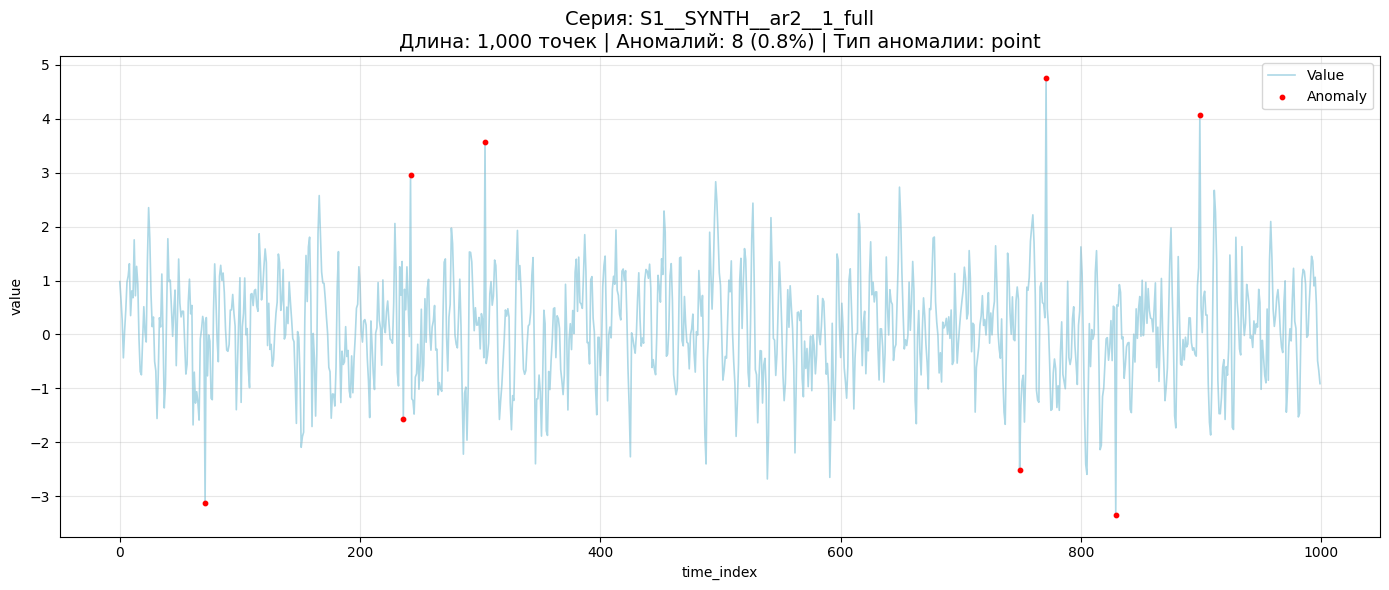

Серия: S1__SYNTH__ar1__2_full | Длина: 1,000 точек | Аномалий: 45 (4.5%) | Тип аномалии: group


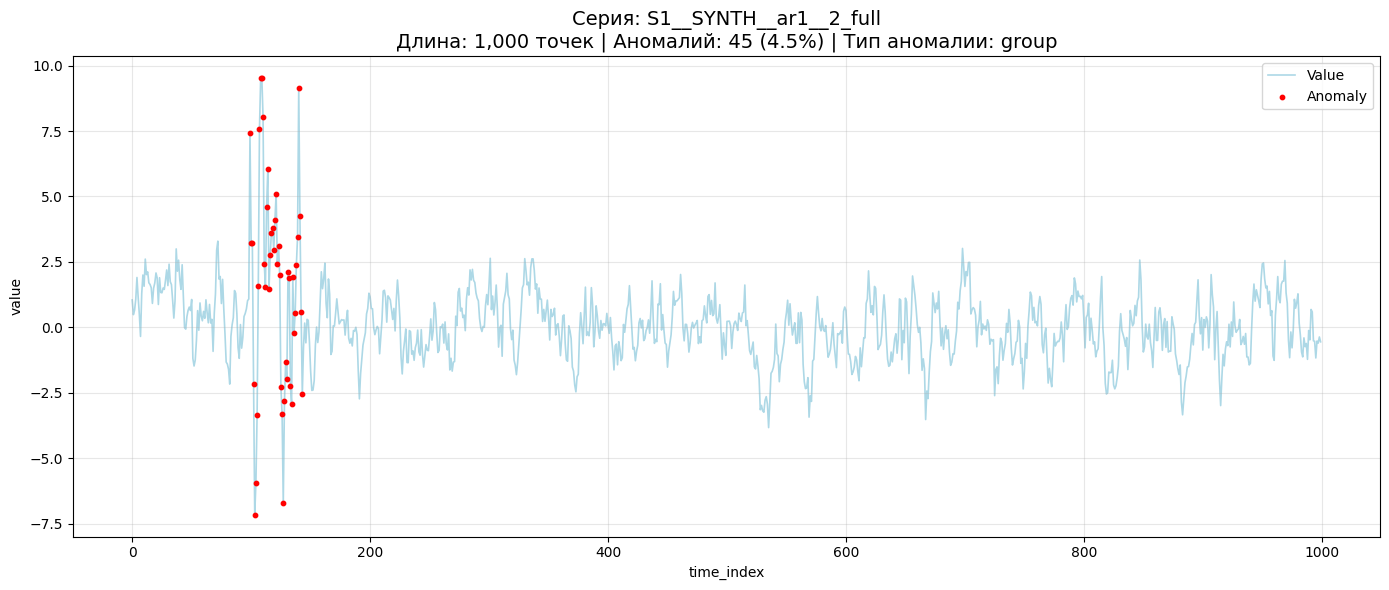

Серия: S1__SYNTH__ar1__3_full | Длина: 1,000 точек | Аномалий: 0 (0.0%) | Тип аномалии: none


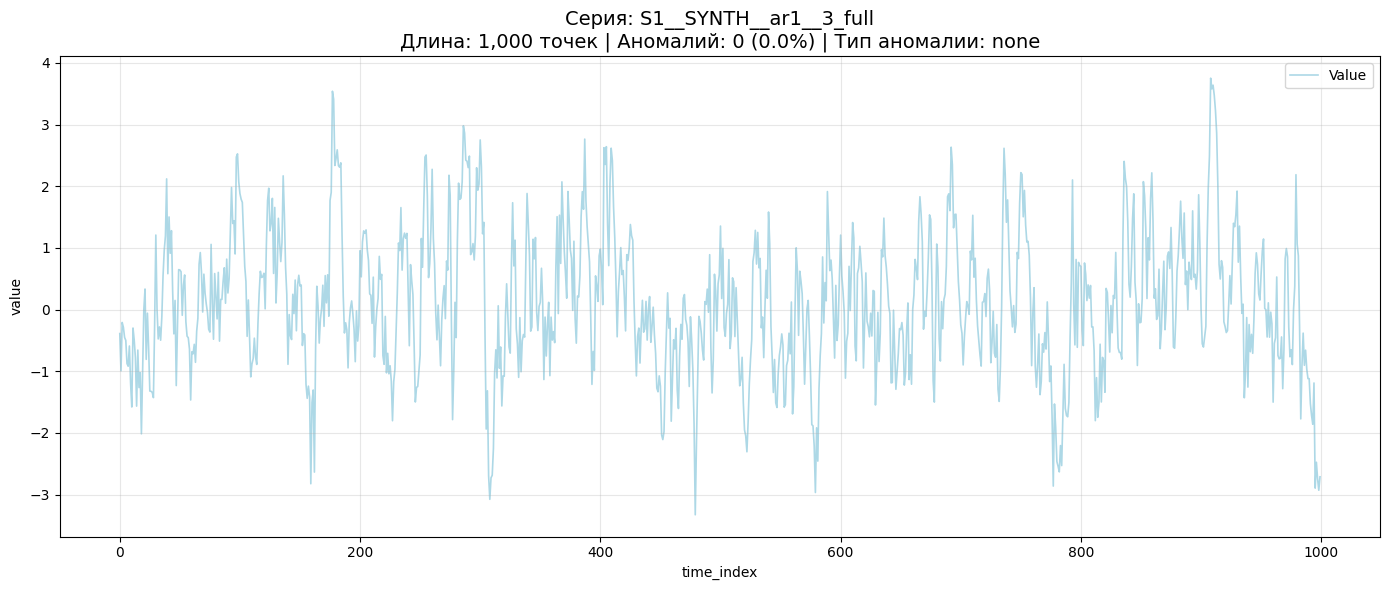

Серия: S1__SYNTH__white_noise__4_full | Длина: 1,000 точек | Аномалий: 0 (0.0%) | Тип аномалии: none


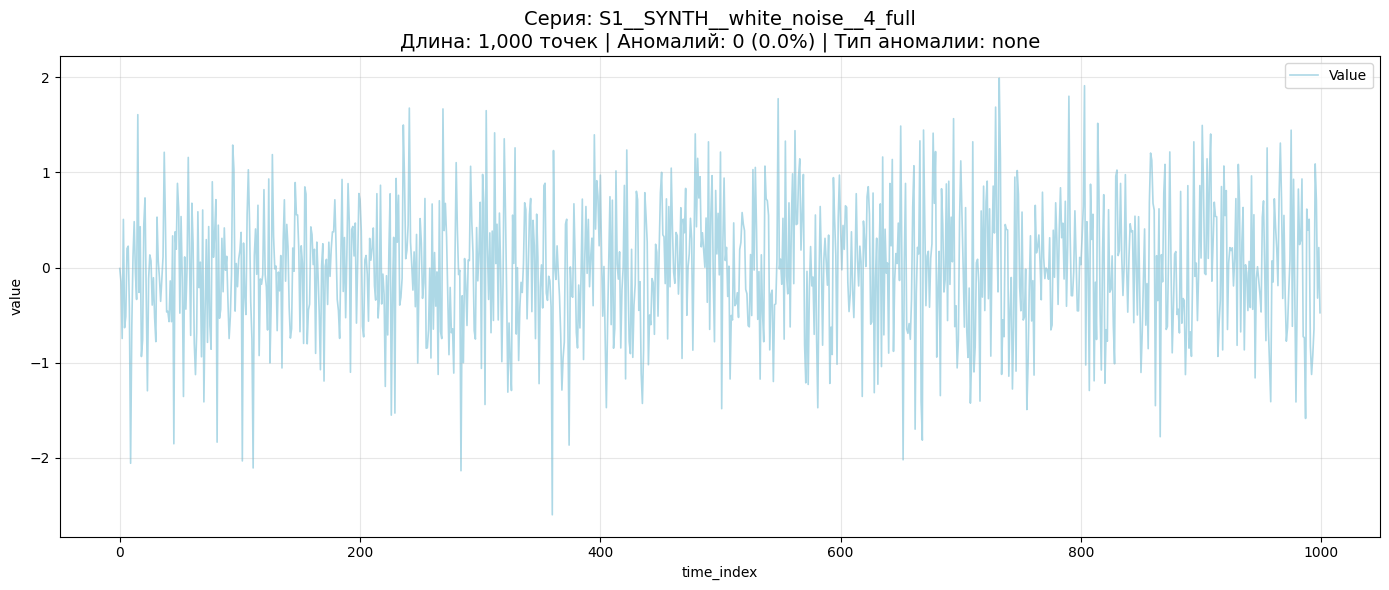

Серия: S1__SYNTH__ar2__5_full | Длина: 1,000 точек | Аномалий: 24 (2.4%) | Тип аномалии: variance


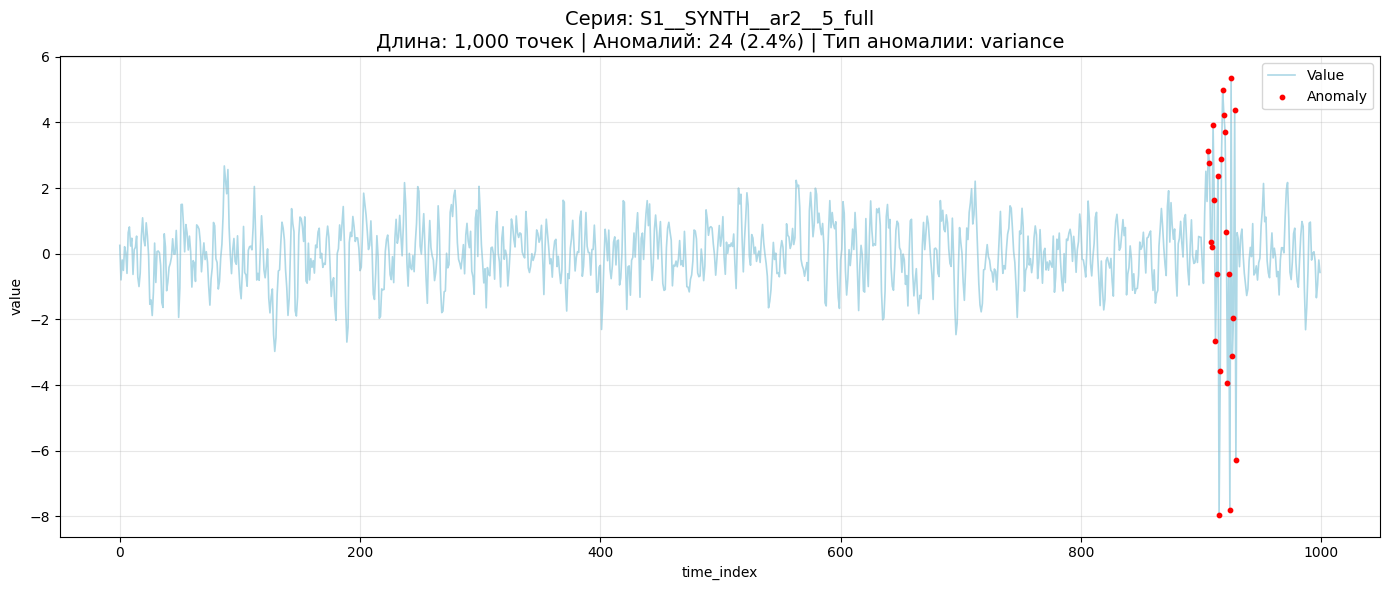

Серия: S1__SYNTH__ar2__6_full | Длина: 1,000 точек | Аномалий: 7 (0.7%) | Тип аномалии: point


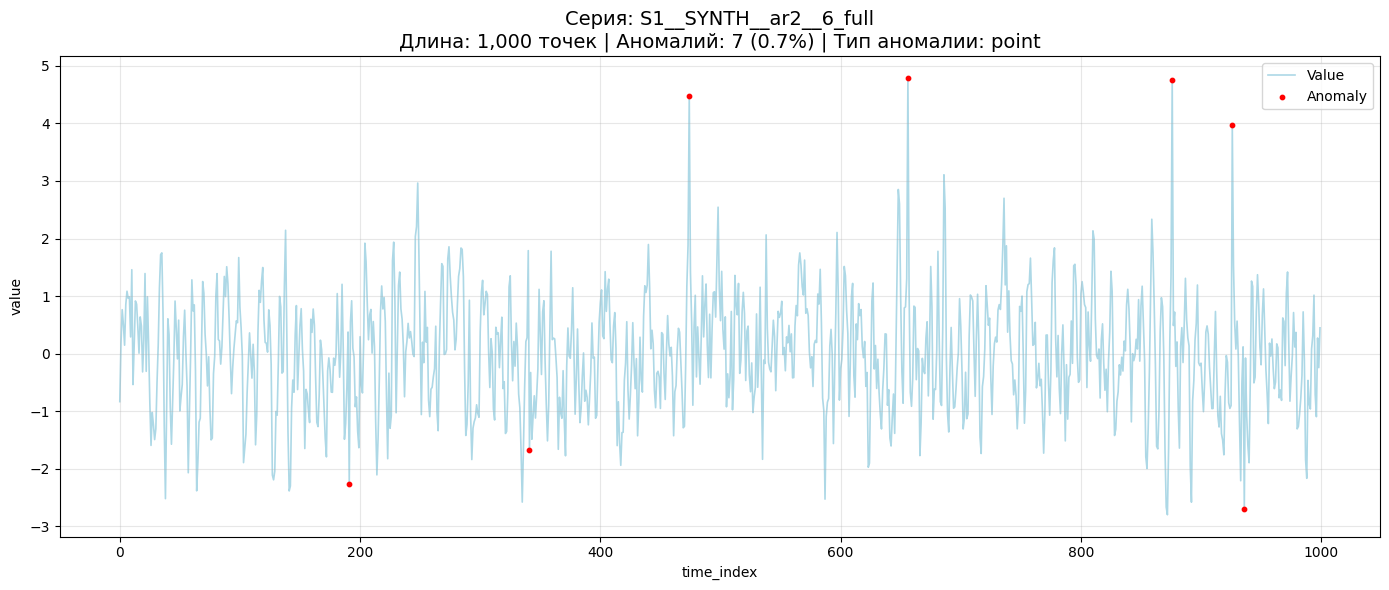

Серия: S1__SYNTH__white_noise__7_full | Длина: 1,000 точек | Аномалий: 45 (4.5%) | Тип аномалии: group


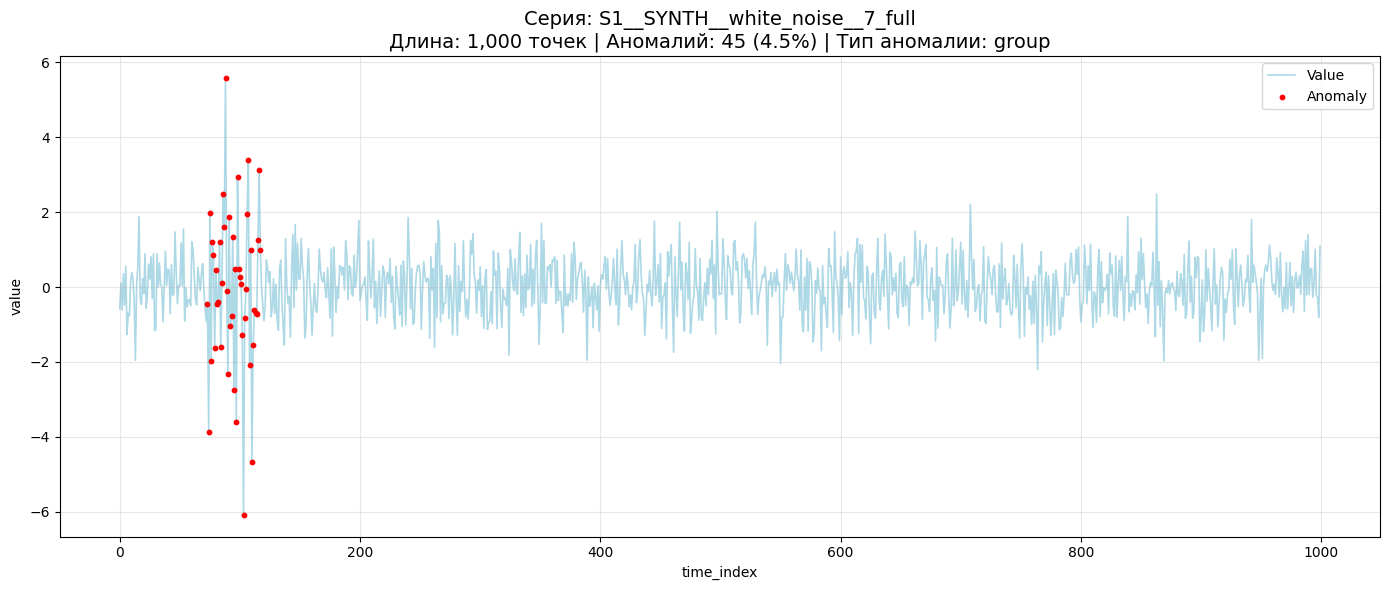

Серия: S1__SYNTH__ar2__8_full | Длина: 1,000 точек | Аномалий: 0 (0.0%) | Тип аномалии: none


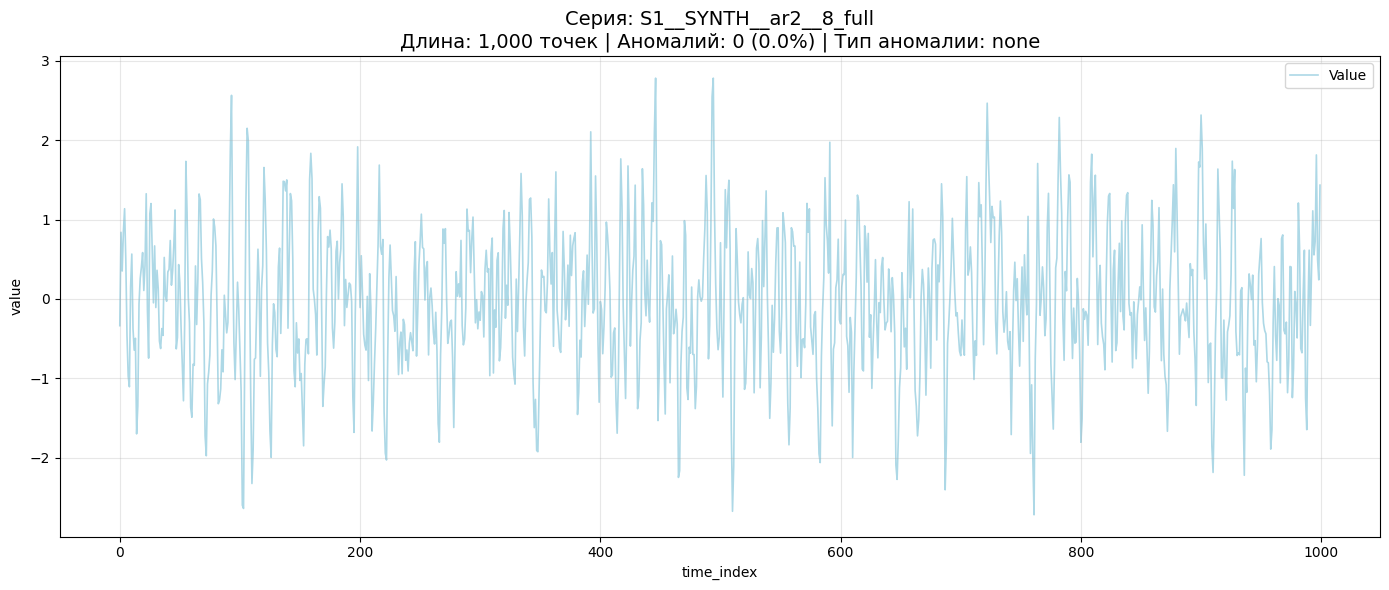

Серия: S1__SYNTH__white_noise__9_full | Длина: 1,000 точек | Аномалий: 52 (5.2%) | Тип аномалии: level_shift


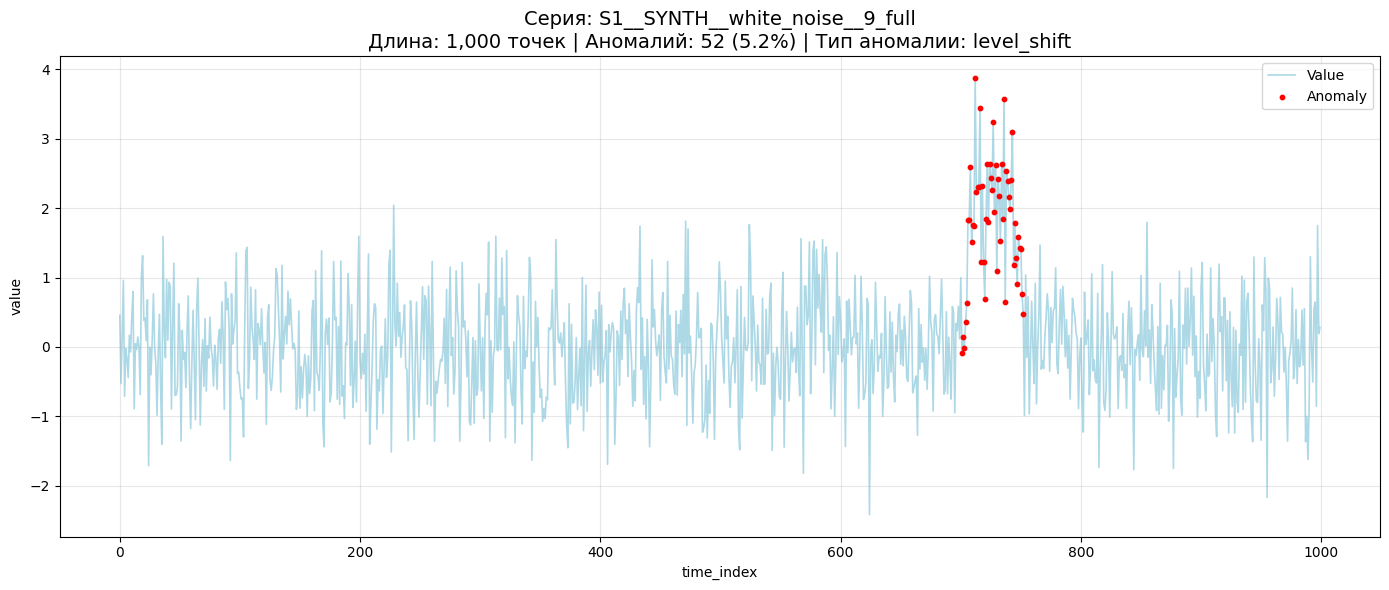

In [38]:
s1_path = "../../data/synthetic/S1.parquet"
s1_meta = pd.read_parquet("../../data/synthetic/S1_metadata.parquet")

unique_series = pd.read_parquet(s1_path)['series_id'].unique()

# Вывод первых 10 рядов пула
for series_id in unique_series[:10]:   
    plot_series(
        pool_file=s1_path,
        series_id=series_id,
        metadata_df=s1_meta   
    )

Серия: S2__SYNTH__trend_seasonal__0_full | Длина: 1,000 точек | Аномалий: 36 (3.6%) | Тип аномалии: group


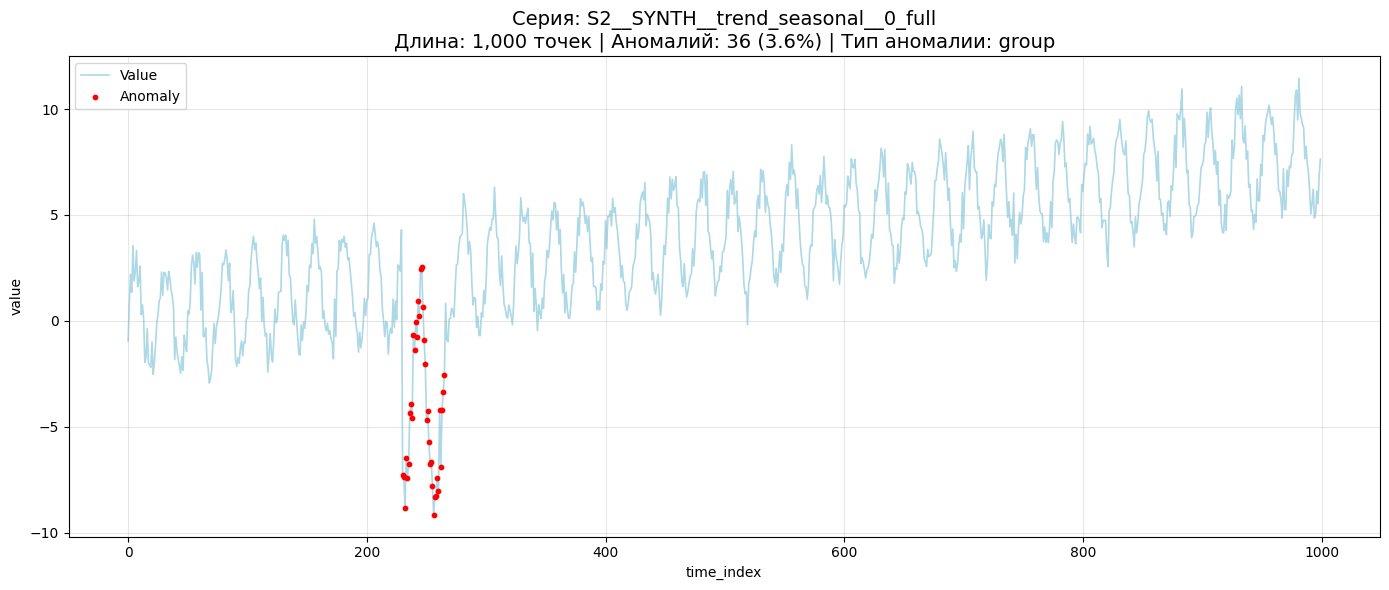

Серия: S2__SYNTH__seasonal_sine__1_full | Длина: 1,000 точек | Аномалий: 31 (3.1%) | Тип аномалии: seasonality


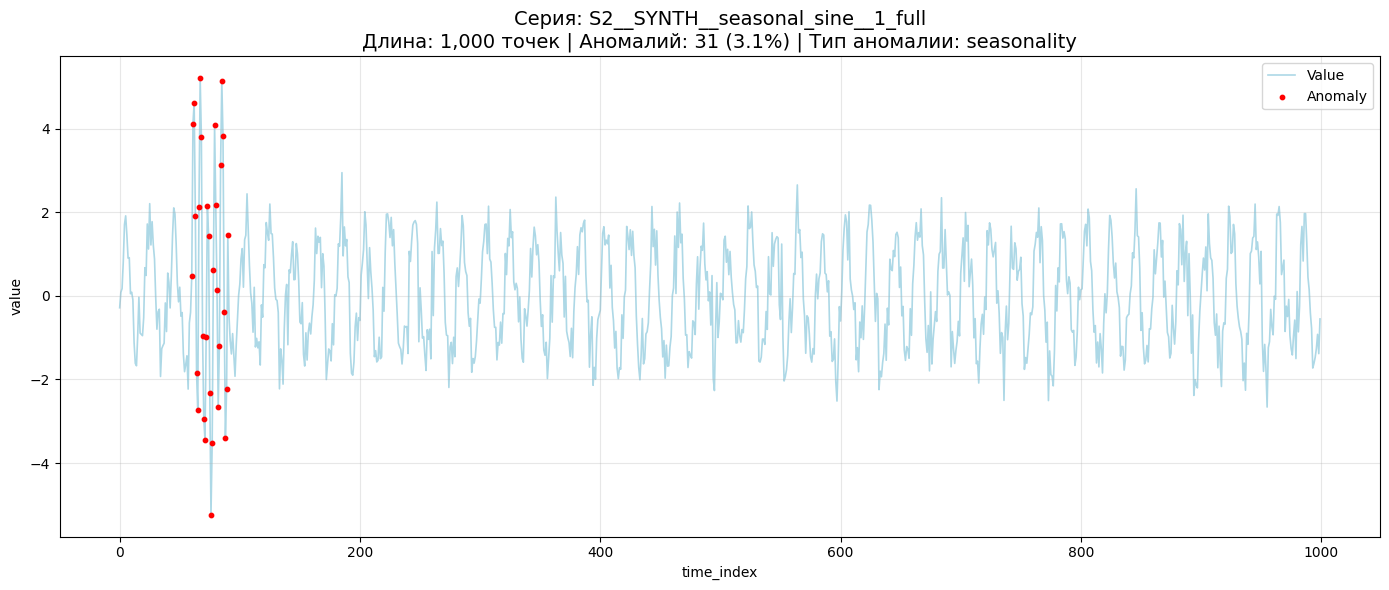

Серия: S2__SYNTH__seasonal_sine__2_full | Длина: 1,000 точек | Аномалий: 31 (3.1%) | Тип аномалии: seasonality


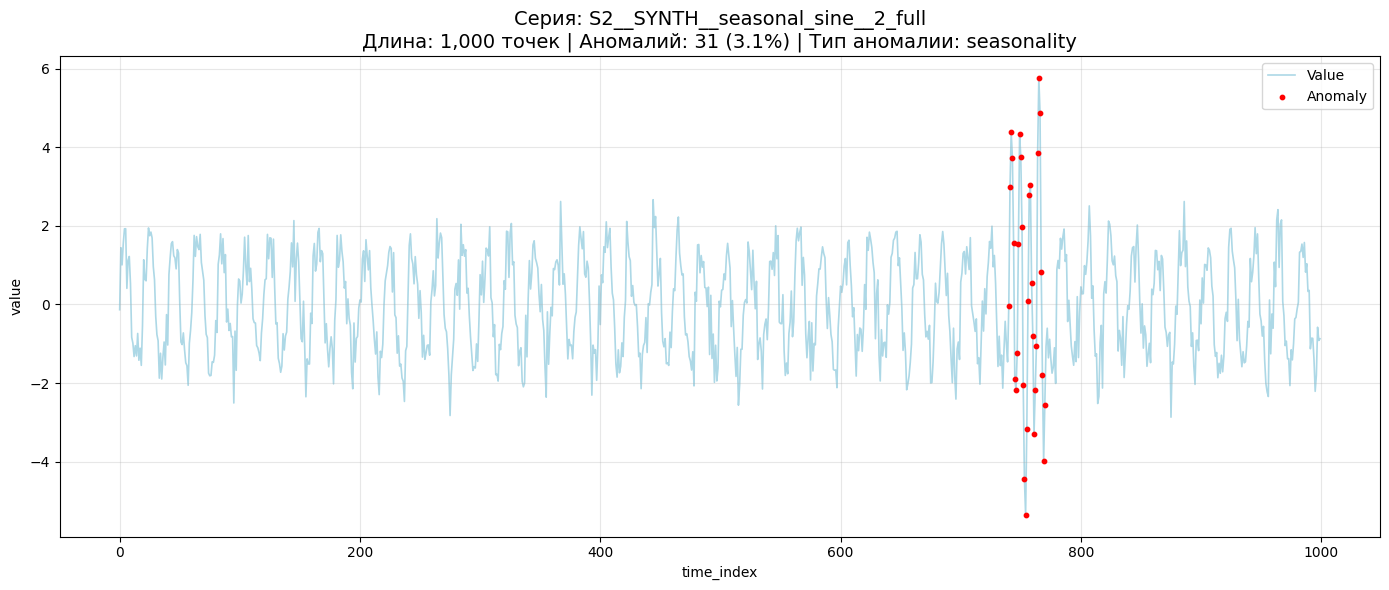

Серия: S2__SYNTH__seasonal_sine__3_full | Длина: 1,000 точек | Аномалий: 39 (3.9%) | Тип аномалии: level_shift


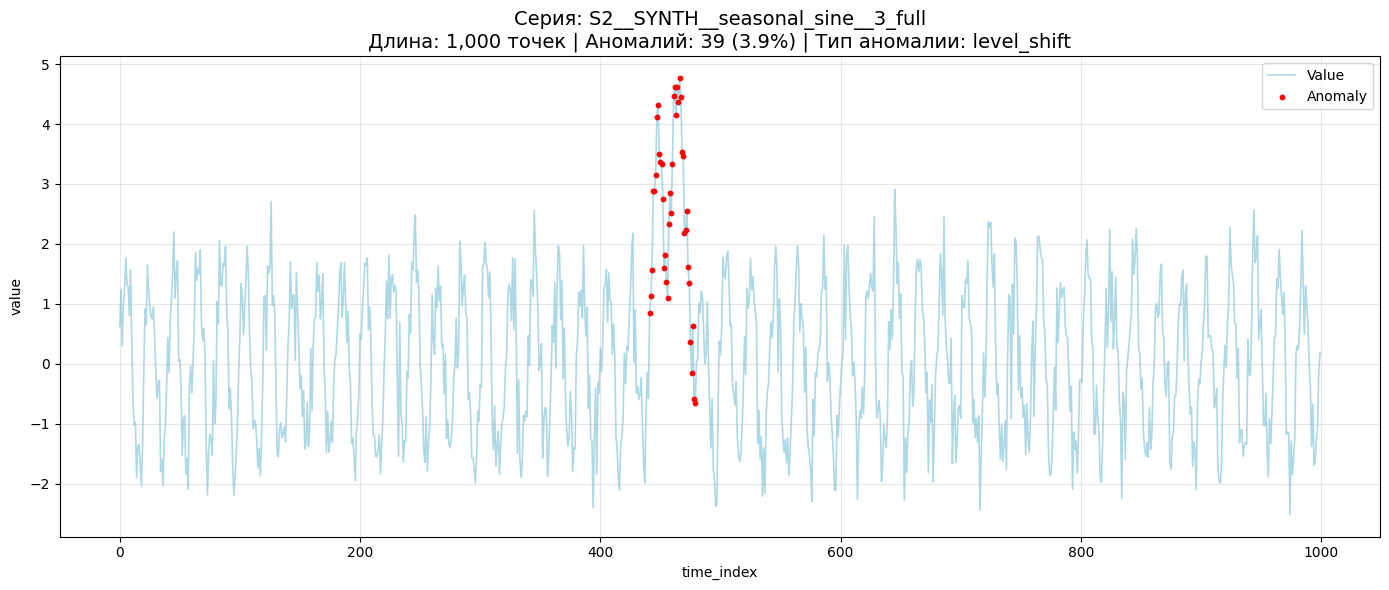

Серия: S2__SYNTH__seasonal_sine__4_full | Длина: 1,000 точек | Аномалий: 49 (4.9%) | Тип аномалии: trend


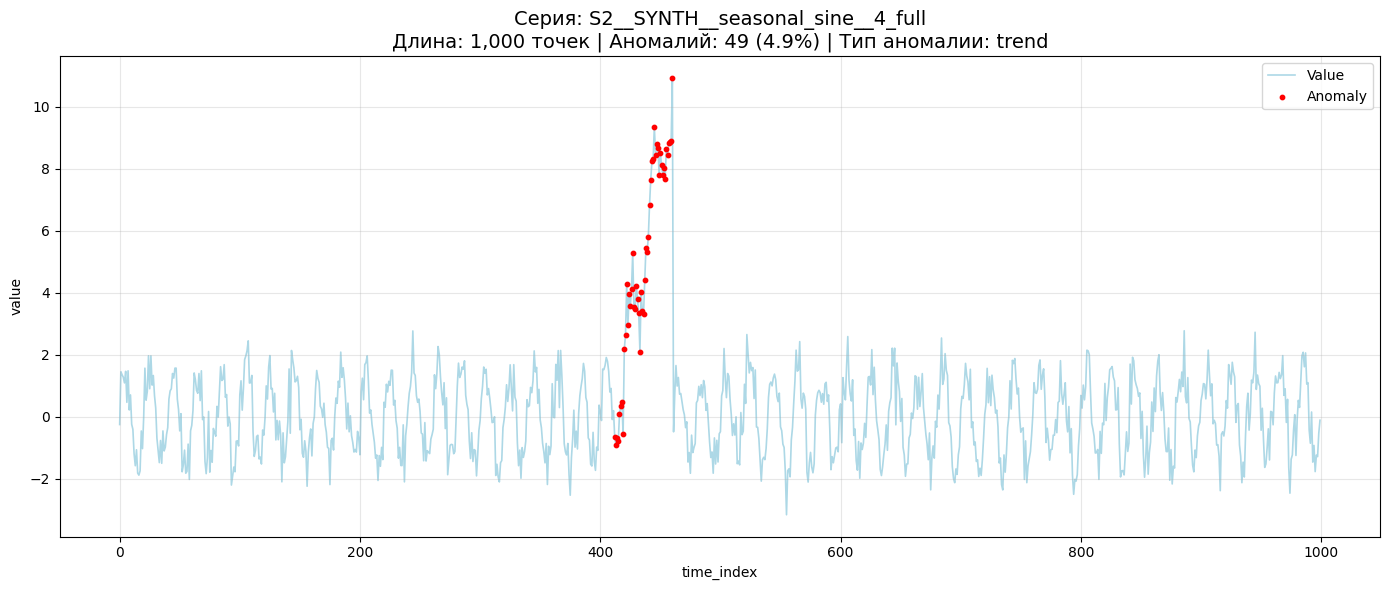

Серия: S2__SYNTH__linear_trend__5_full | Длина: 1,000 точек | Аномалий: 32 (3.2%) | Тип аномалии: seasonality


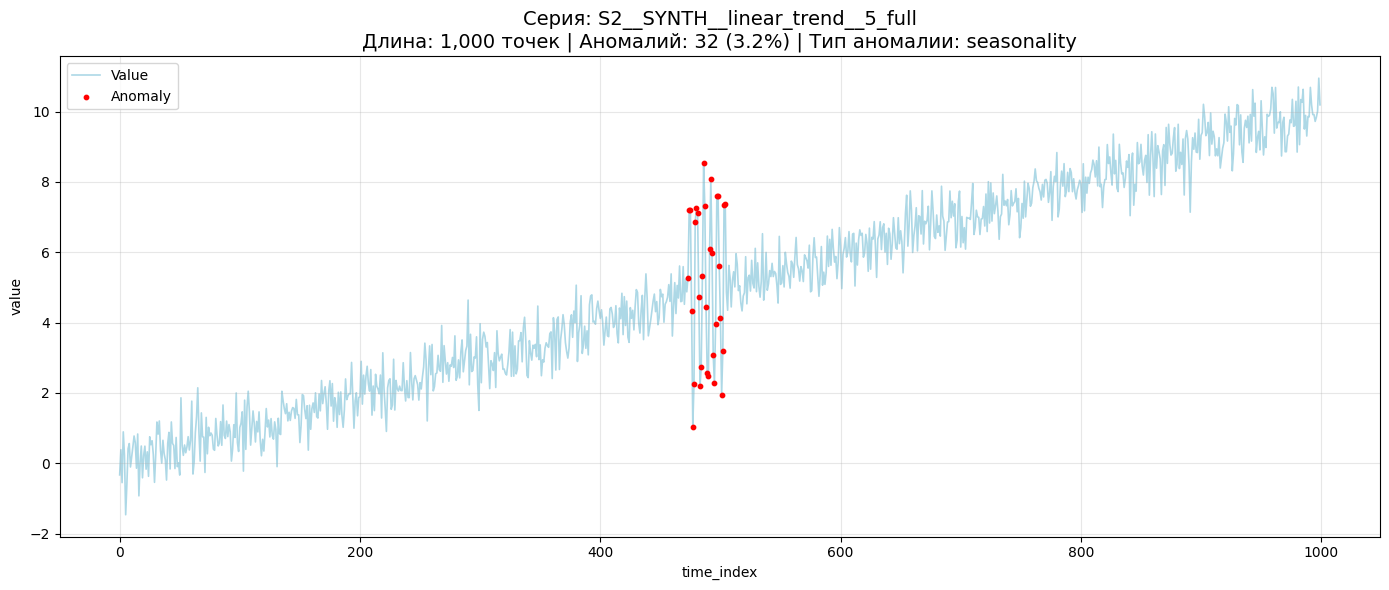

Серия: S2__SYNTH__seasonal_sine__6_full | Длина: 1,000 точек | Аномалий: 0 (0.0%) | Тип аномалии: none


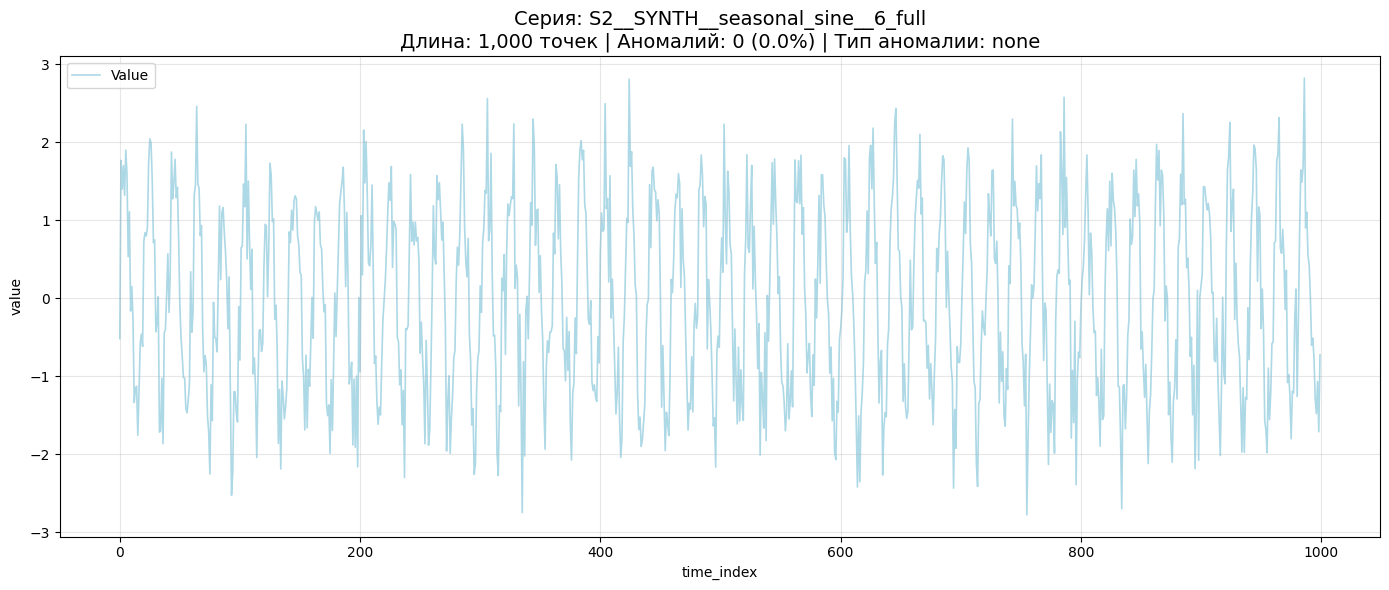

Серия: S2__SYNTH__trend_seasonal__7_full | Длина: 1,000 точек | Аномалий: 57 (5.7%) | Тип аномалии: trend


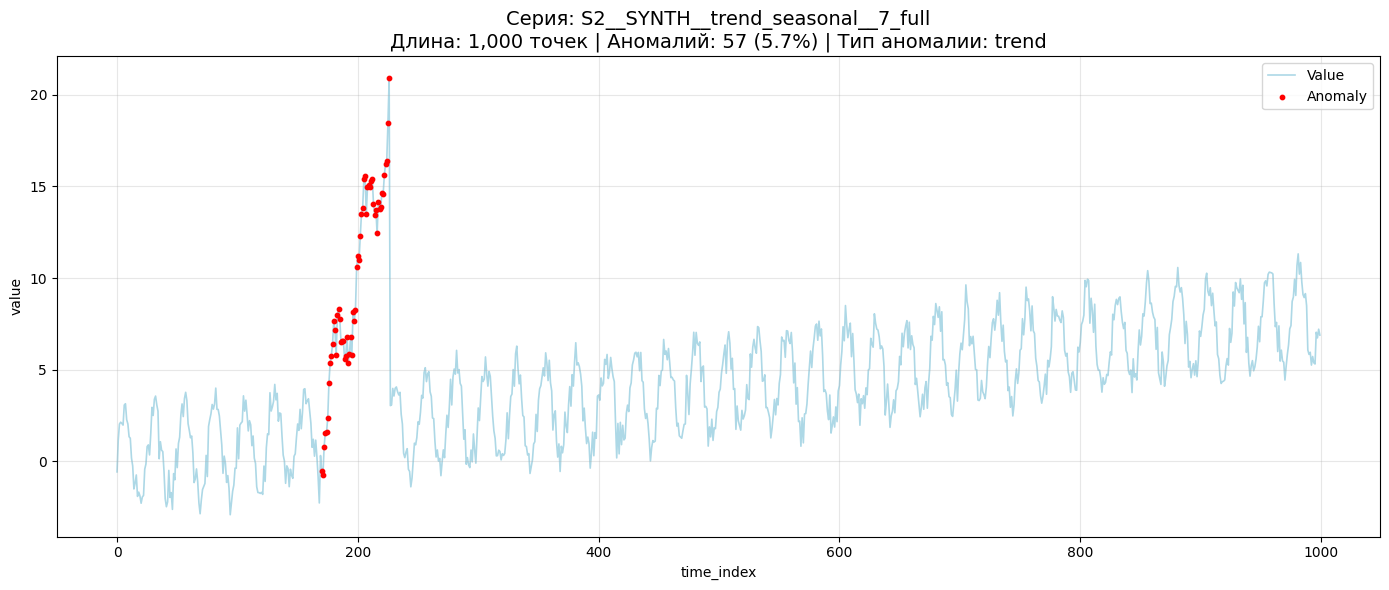

Серия: S2__SYNTH__seasonal_sine__8_full | Длина: 1,000 точек | Аномалий: 41 (4.1%) | Тип аномалии: level_shift


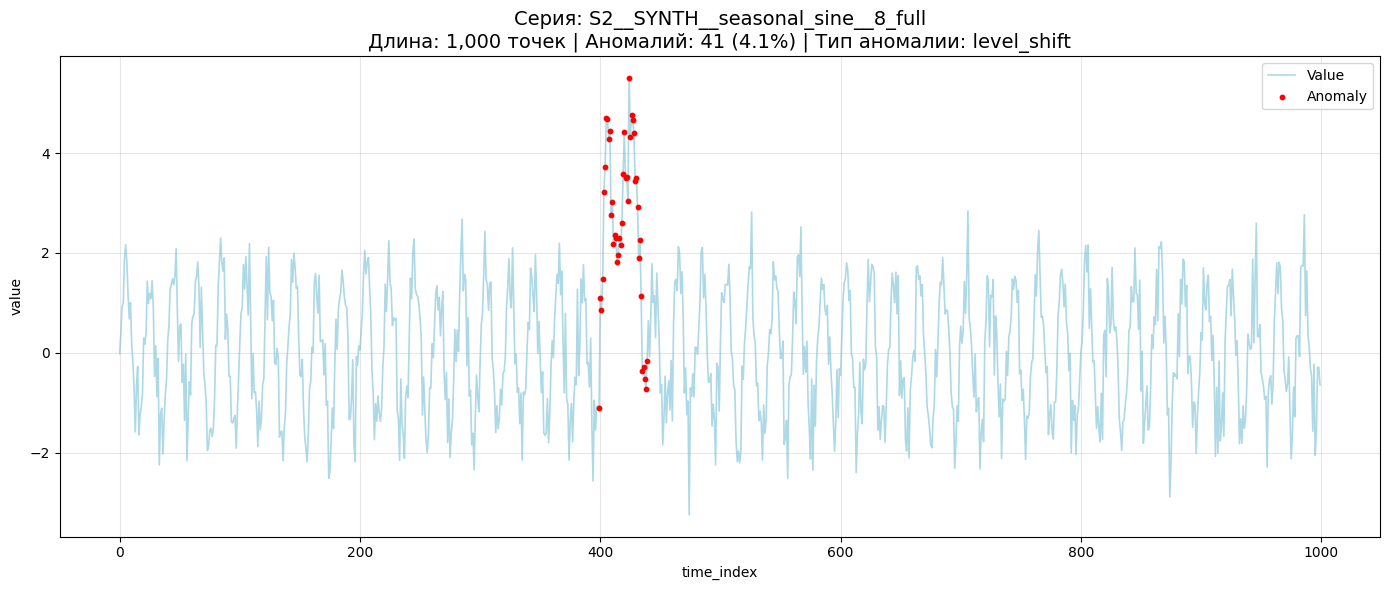

Серия: S2__SYNTH__seasonal_sine__9_full | Длина: 1,000 точек | Аномалий: 26 (2.6%) | Тип аномалии: level_shift


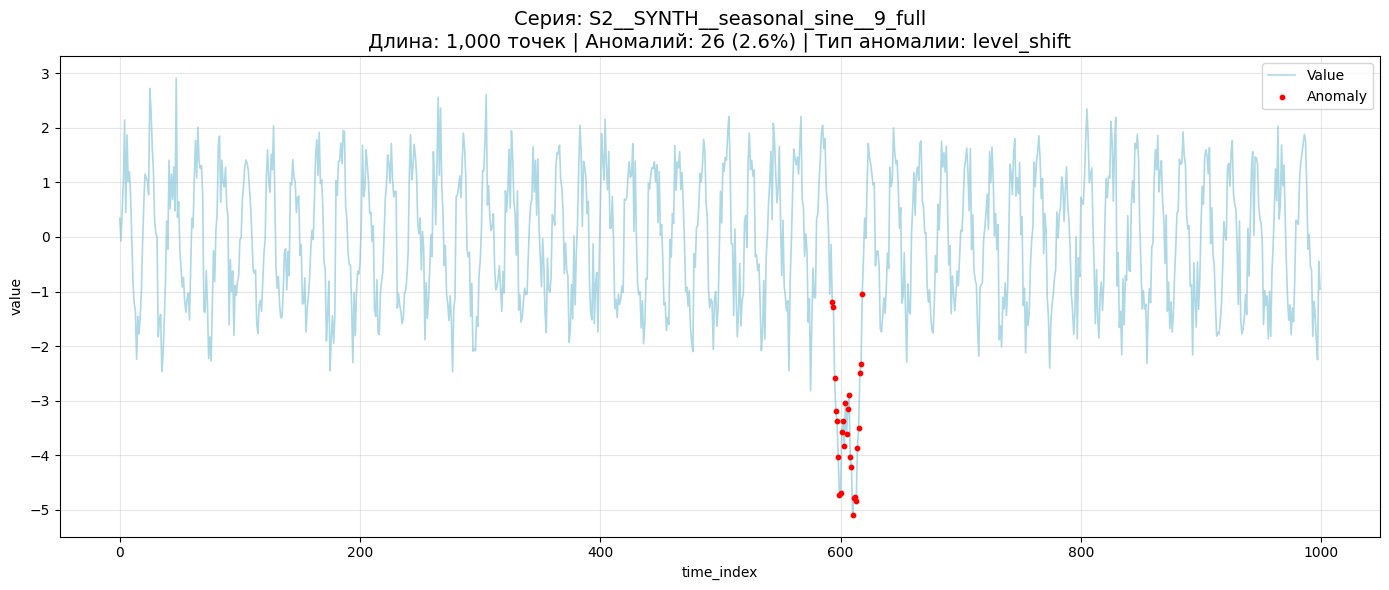

In [39]:
s2_path = "../../data/synthetic/S2.parquet"   
s2 = pd.read_parquet(s2_path)
s2_meta = pd.read_parquet("../../data/synthetic/S2_metadata.parquet")
unique_series = s2['series_id'].unique()

for i, series_id in enumerate(unique_series[:10]):
    plot_series(
        pool_file=s2_path,
        series_id=series_id,
        metadata_df=s2_meta,
        # start=500, end=800   
    )